In [4]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
import pandas as pd
!pip install scikit-fuzzy
from skfuzzy.cluster import cmeans
from sklearn.preprocessing import StandardScaler
from google.colab import files

In [5]:
def BIC(K, grupos, X):
    N, P = X.shape
    xi = np.zeros((1, K))

    for k in range(K):
        suma = 0
        for j in range(P):
            sigma = np.square(np.std(X[:, j]))
            sigma_j = np.square(np.std(X[grupos == k, j]))
            suma += 0.5 * np.log(sigma + sigma_j)

        n_k = sum(grupos == k)
        xi[0, k] = -n_k * suma

    bic = -2 * np.sum(xi) + 2 * K * P * np.log(N)
    return bic

#Tarea 1. Carga de datos y análisis previo


#1.1. Carga el dataset en clientes

In [6]:
url = 'https://drive.google.com/uc?export=download&id=1NhUghxZk2SQzmkTrkk-yNvYCPPOHSjpQ'
clientes = pd.read_csv(url)

#1.2. Muestra un resumen estadístico del dataset de forma numérica

In [7]:
print(clientes.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


#1.3. Muestra al menos tres gráficos estadísticos sobre el dataset, elige los que creas más oportunos.

Gráfico 1: Histograma de la edad de los clientes

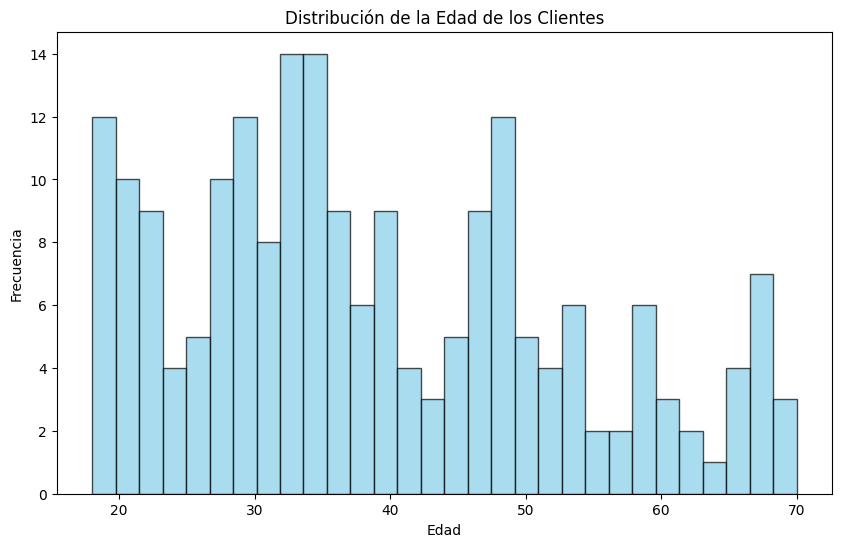

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(clientes['Age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de la Edad de los Clientes')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

Gráfico 2: Gráfico de dispersión de Edad vs. Ingresos Anuales

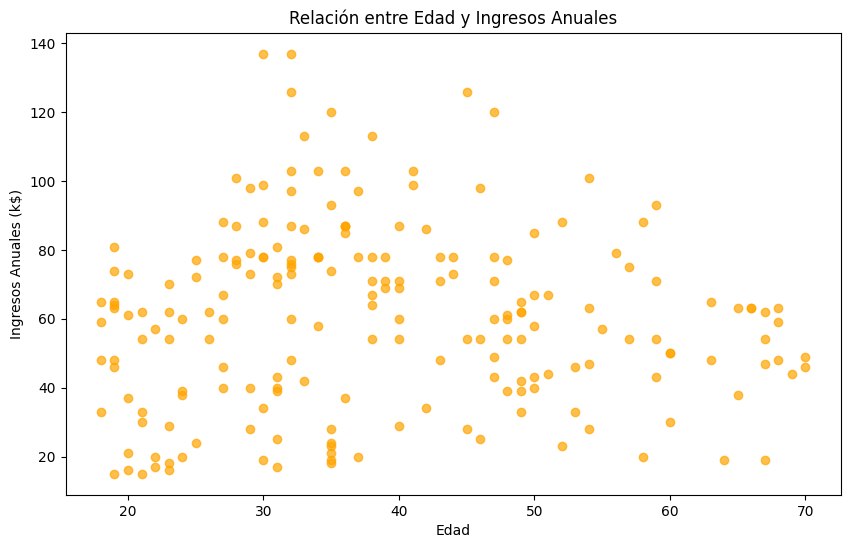

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(clientes['Age'], clientes['Annual Income (k$)'], color='orange', alpha=0.7)
plt.title('Relación entre Edad y Ingresos Anuales')
plt.xlabel('Edad')
plt.ylabel('Ingresos Anuales (k$)')
plt.show()

Gráfico 3: Gráfico de dispersión de Edad vs. Spending Score

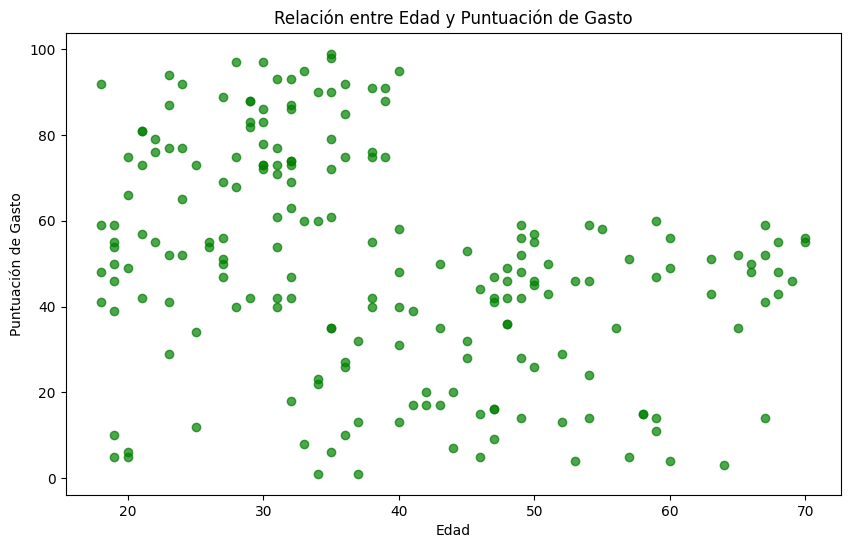

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(clientes['Age'], clientes['Spending Score (1-100)'], color='green', alpha=0.7)
plt.title('Relación entre Edad y Puntuación de Gasto')
plt.xlabel('Edad')
plt.ylabel('Puntuación de Gasto')
plt.show()


#1.4. Modifica la columna Gender de clientes, codificándola con un 0 para Male y un 1 para Female.

In [11]:
clientes['Gender'] = clientes['Gender'].map({'Male': 0, 'Female': 1})
print(clientes.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1       0   19                  15                      39
1           2       0   21                  15                      81
2           3       1   20                  16                       6
3           4       1   23                  16                      77
4           5       1   31                  17                      40


#1.5. Crea un nuevo dataset llamado clientes_std, que contenga a clientes con los atributos escalados por el método de estandarización gaussiano

In [12]:
datosEscalar = clientes[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
clientes_std = clientes.copy()
clientes_std[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']] = scaler.fit_transform(datosEscalar)
print(clientes_std.head())

   CustomerID  Gender       Age  Annual Income (k$)  Spending Score (1-100)
0           1       0 -1.424569           -1.738999               -0.434801
1           2       0 -1.281035           -1.738999                1.195704
2           3       1 -1.352802           -1.700830               -1.715913
3           4       1 -1.137502           -1.700830                1.040418
4           5       1 -0.563369           -1.662660               -0.395980


#Tarea 2 Clustering con KMeans

#2.1. Mediante BIC calcula el nº óptimo de grupos para KMeans con clientes_std.Representa gráficamente los valores de BIC obtenidos y muestra numéricamente el valor de BIC para el mejor de los resultados.

In [13]:
X = clientes_std[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values
BIC_array = []
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k,  n_init=10, random_state=10)
    grupos = kmeans.fit_predict(X)
    BIC_array .append(BIC(k, grupos, X))


# Selección del número óptimo de clusters
k_optimo = np.argmin(BIC_array)+1
print(f'Número óptimo de clusters según BIC: {k_optimo}')

Número óptimo de clusters según BIC: 4


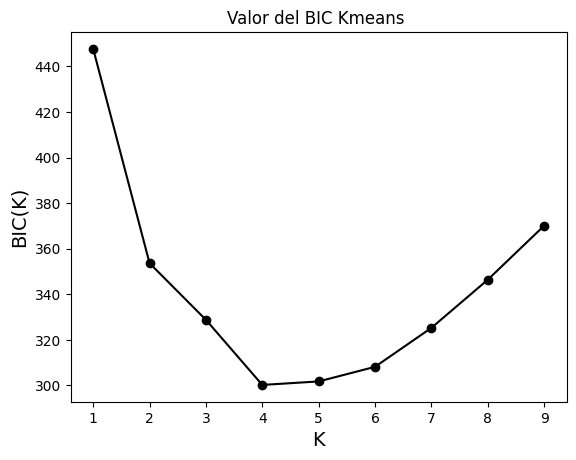

In [14]:
#Gráfica de valores del BIC
plt.plot(k_range, BIC_array , "ko-")
plt.title("Valor del BIC en función de K", fontsize=16)
plt.xlabel("K", fontsize=14)
plt.ylabel("BIC(K)", fontsize=14)
plt.title("Valor del BIC Kmeans ")
plt.show()

#2.2. Realiza el agrupamiento de clientes_std usando KMeans , con el valor óptimo de k obtenido en el paso anterior.

In [15]:
kmeans_optimo = KMeans(n_clusters=k_optimo, random_state=10, n_init=10)
kmeans_optimo.fit(X)
predicciones = kmeans_optimo.predict(X)
centroides = kmeans_optimo.cluster_centers_
#print(predicciones)
#print(centroides)

#2.3. Crea el dataset clientes_kmeans, que contendrá a clientes_std, con una columna añadida con el grupo al que pertenece cada fila. Muestra los centroides del agrupamiento y la “tabla” clientes_kmeans.

In [16]:
clientes_kmeans = clientes_std.copy()
clientes_kmeans["Grupo"] = predicciones

print("Centroides:")
print(centroides)

Centroides:
[[ 0.03720536  0.99011499 -1.18875705]
 [-0.42880597  0.97484722  1.21608539]
 [ 1.08616125 -0.49056525 -0.39717443]
 [-0.96249203 -0.78476346  0.39202966]]


In [17]:
print("Tabla:")
print(clientes_kmeans)

Tabla:
     CustomerID  Gender       Age  Annual Income (k$)  Spending Score (1-100)  \
0             1       0 -1.424569           -1.738999               -0.434801   
1             2       0 -1.281035           -1.738999                1.195704   
2             3       1 -1.352802           -1.700830               -1.715913   
3             4       1 -1.137502           -1.700830                1.040418   
4             5       1 -0.563369           -1.662660               -0.395980   
..          ...     ...       ...                 ...                     ...   
195         196       1 -0.276302            2.268791                1.118061   
196         197       1  0.441365            2.497807               -0.861839   
197         198       0 -0.491602            2.497807                0.923953   
198         199       0 -0.491602            2.917671               -1.250054   
199         200       0 -0.635135            2.917671                1.273347   

     Grupo  
0      

#2.4. Muestra un gráfico donde se representen los atributos Annual Income y Spending Score de clientes_std, con el color del grupo al que los ha asignado Kmeans. Muestra también en el gráfico los centroides del agrupamiento.

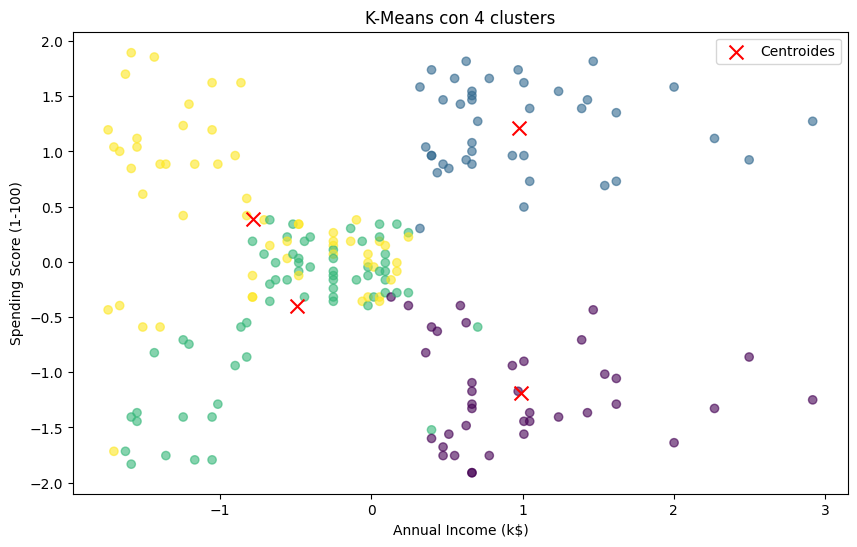

In [18]:
x_centroides, y_centroides = centroides[:, 1], centroides[:, 2]
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 1], X[:, 2], c=predicciones, cmap='viridis', alpha=0.6)
plt.scatter(x_centroides, y_centroides, c='red', marker='x', s=100, label='Centroides')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'K-Means con {k_optimo} clusters')
plt.legend()
plt.show()

#Tarea 3.Clustering con Fuzzy-C.

#3.1. Mediante BIC calcula el nº óptimo de grupos para Fuzzy-C con clientes_std. Representa gráficamente los valores de BIC obtenidos y muestra numéricamente el valor de BIC para el mejor de los resultados.

In [19]:
BIC_scores_fuzzy = []
k_range_fuzzy = range(1, 10)
for k in k_range_fuzzy:
    cntr, u, _, _, _, _, fcp = cmeans(X.T, k, m=2, error=0.005, maxiter=1000)
    grupos = np.argmax(u, axis=0)
    BIC_scores_fuzzy.append(BIC(k,grupos,X))


k_optimo_fuzzy = np.argmin(BIC_scores_fuzzy) + 1
print(f'Número óptimo de clusters según BIC para Fuzzy-C: {k_optimo_fuzzy}')


Número óptimo de clusters según BIC para Fuzzy-C: 4


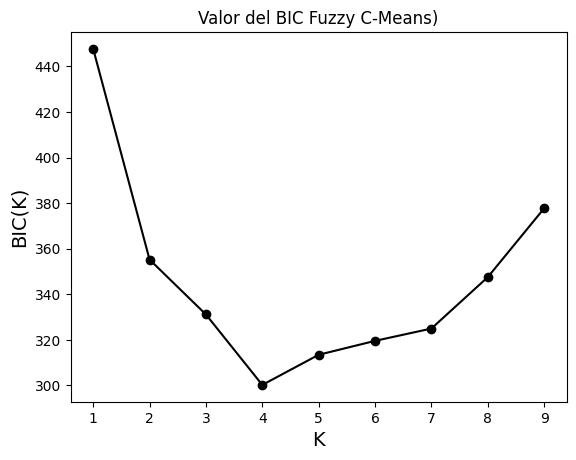

In [20]:
# Gráfica de BIC para Fuzzy-C
plt.plot(k_range_fuzzy, BIC_scores_fuzzy, "ko-")
plt.xlabel("Número de clusters (K)",fontsize=16)
plt.xlabel("K", fontsize=14)
plt.ylabel("BIC(K)", fontsize=14)
plt.title("Valor del BIC Fuzzy C-Means)")
plt.show()


#3.2. Realiza el agrupamiento de clientes_std usando Fuzzy-C, con el valor óptimo de k obtenido en el paso anterior.

In [21]:
cntr, u, u0, d, jm, iteraciones, fpc = cmeans(X.T, k_optimo_fuzzy, m=2, error=0.005, maxiter=1000, init=None)

#3.3. Crea el dataset clientes_fuzzy, que contendrá a clientes_std, con una columna añadida con el grupo al que pertenece cada fila. Muestra los centroides del agrupamiento y la “tabla” clientes_fuzzy

In [22]:
grupos_fuzzy = np.argmax(u, axis=0)

clientes_fuzzy = clientes_std.copy()
clientes_fuzzy["Grupo"] = grupos_fuzzy

# Mostrar los centroides
print("Centroides de Fuzzy C-Means:")
print(cntr)

Centroides de Fuzzy C-Means:
[[ 1.10500996 -0.37014839 -0.21155626]
 [ 0.18797545  0.79880074 -1.16193742]
 [-0.45658667  0.78651671  1.13147164]
 [-0.88729528 -0.75627004  0.33258392]]


In [23]:
# Mostrar la tabla clientes_fuzzy
print("\nPrimeras filas de clientes_fuzzy:")
print(clientes_fuzzy)


Primeras filas de clientes_fuzzy:
     CustomerID  Gender       Age  Annual Income (k$)  Spending Score (1-100)  \
0             1       0 -1.424569           -1.738999               -0.434801   
1             2       0 -1.281035           -1.738999                1.195704   
2             3       1 -1.352802           -1.700830               -1.715913   
3             4       1 -1.137502           -1.700830                1.040418   
4             5       1 -0.563369           -1.662660               -0.395980   
..          ...     ...       ...                 ...                     ...   
195         196       1 -0.276302            2.268791                1.118061   
196         197       1  0.441365            2.497807               -0.861839   
197         198       0 -0.491602            2.497807                0.923953   
198         199       0 -0.491602            2.917671               -1.250054   
199         200       0 -0.635135            2.917671                1.273

#3.4. Muestra un gráfico donde se representen los atributos Annual Income y Spending Score de clientes_std, con el color del grupo al que los ha asignado Fuzzy-C y el grado de pertenencia a su grupo. Muestra también en el gráfico los centroides del agrupamiento.

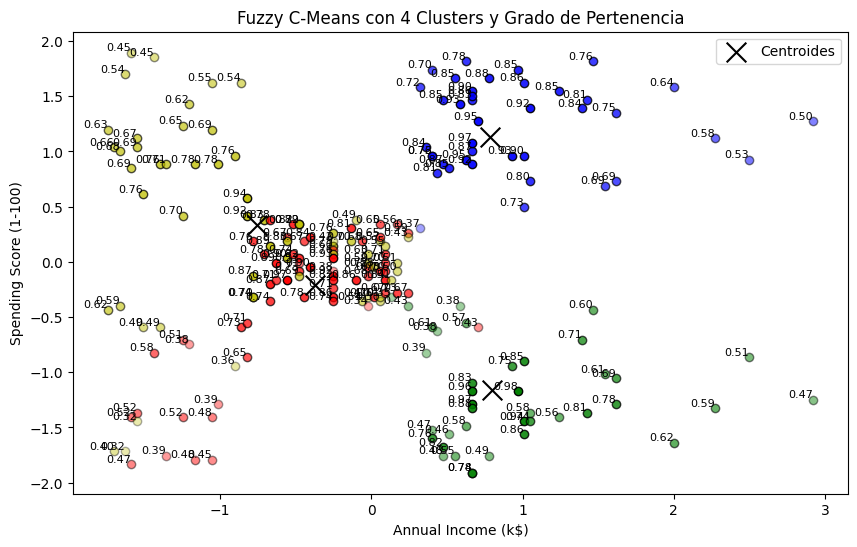

In [24]:
plt.figure(figsize=(10, 6))
colors = ['r', 'g', 'b', 'y']
for i in range(len(X)):
    cluster = grupos_fuzzy[i]
    alpha = u[cluster, i]
    plt.scatter(X[i, 1], X[i, 2], color=colors[cluster], alpha=alpha, edgecolors='k')
    plt.text(X[i, 1], X[i, 2], f"{u[cluster, i]:.2f}", fontsize=8, ha='right', va='bottom', color='black')

# Graficar centroides
plt.scatter(cntr[:, 1], cntr[:, 2], marker='x', s=200, color='k', label='Centroides')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Fuzzy C-Means con {k_optimo_fuzzy} Clusters y Grado de Pertenencia')
plt.legend()
plt.show()

#4.1. Crea el dataframe clientes_agrupados, que contendrá a clientes (no a clientes_std)más dos columnas: El grupo al que lo asignó Kmeans y el grupo al que lo asignó Fuzzy-C.

In [25]:
clientes_agrupados = clientes.copy()
clientes_agrupados["Grupo_KMeans"] = clientes_kmeans["Grupo"]
clientes_agrupados["Grupo_FuzzyC"] = clientes_fuzzy["Grupo"]
print(clientes_agrupados.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       0   19                  15                      39   
1           2       0   21                  15                      81   
2           3       1   20                  16                       6   
3           4       1   23                  16                      77   
4           5       1   31                  17                      40   

   Grupo_KMeans  Grupo_FuzzyC  
0             3             3  
1             3             3  
2             3             3  
3             3             3  
4             3             3  


#4.2. Guarda el dataset clientes_agrupados en el disco local del equipo donde se esté ejecutando el cuaderno de Google Colab, con el nombre clientes_agrupados_nombre_apellido1_apellido2.csv

In [ ]:
nombre_archivo = "clientes_agrupados.csv"
clientes_agrupados.to_csv(nombre_archivo, index=False)
files.download(nombre_archivo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#4.3. Redacta, en un cuadro de texto, un análisis completo de los resultados obtenidos.

El análisis de clustering con K-Means y Fuzzy C-Means ha mostrado para ambos que la manera más optima de dividir es en 4 grupos segun el BIC. K-Means ha generado agrupaciones más definidas y sólidas, mientras que Fuzzy C-Means, aunque bastante parecido, al utilizar grados de pertenencia es más útil para clientes con características intermedias.